Project: Battery Drain Prediction (with Kaggle Dataset) 📦 Dataset from Kaggle

Use this dataset:

👉 Mobile Device Usage and User Behavior Dataset

Search that exact name on Kaggle and download the CSV.

📊 What’s inside the dataset?

Typical columns you’ll see:

App Usage Time (min/day) Screen On Time (hours/day) Battery Drain (mAh/day) Number of Apps Installed Data Usage (MB/day) 🎯 Your Goal

Predict:

👉 Battery Drain (mAh/day)

using:

👉 Screen On Time (hours/day)

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [10]:
df = pd.read_csv("user_behavior_dataset.csv")

# Display first 5 rows
print(df.head())

   User ID    Device Model Operating System  App Usage Time (min/day)  \
0        1  Google Pixel 5          Android                       393   
1        2       OnePlus 9          Android                       268   
2        3    Xiaomi Mi 11          Android                       154   
3        4  Google Pixel 5          Android                       239   
4        5       iPhone 12              iOS                       187   

   Screen On Time (hours/day)  Battery Drain (mAh/day)  \
0                         6.4                     1872   
1                         4.7                     1331   
2                         4.0                      761   
3                         4.8                     1676   
4                         4.3                     1367   

   Number of Apps Installed  Data Usage (MB/day)  Age  Gender  \
0                        67                 1122   40    Male   
1                        42                  944   47  Female   
2                

In [11]:
# Select input and output
X = df[["Screen On Time (hours/day)"]]   # Independent variable
y = df["Battery Drain (mAh/day)"]        # Target variable

# Split dataset into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [12]:
# Create model
model = LinearRegression()

# Train model
model.fit(X_train, y_train)

# Predict values
y_pred = model.predict(X_test)

# Print model equation
print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)

# Evaluate model
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

Slope: 254.44924451031176
Intercept: 184.13665682542387
MAE: 205.7835278075701
R2 Score: 0.892433026042035


In [13]:
# Predict for a sample value
sample = pd.DataFrame([[5]], columns=X.columns)   # 5 hours screen time
prediction = model.predict(sample)
print("Predicted battery drain for 5 hours:", prediction[0])

Predicted battery drain for 5 hours: 1456.3828793769826


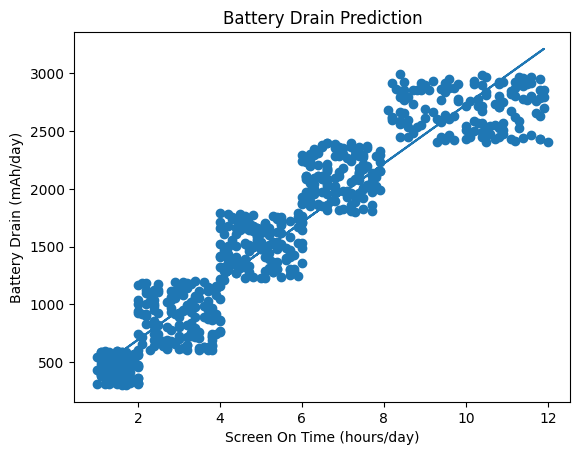

In [14]:
# Plot graph
plt.scatter(X, y)
plt.plot(X_test, y_pred)
plt.xlabel("Screen On Time (hours/day)")
plt.ylabel("Battery Drain (mAh/day)")
plt.title("Battery Drain Prediction")
plt.show()